# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

##Answer

# Gaussian Process Regression for Multi-Output Energy Efficiency Modeling

This analysis explores the feasibility and mathematical framework of modeling two interdependent thermal responses—**Heating Load ($Y_1$)** and **Cooling Load ($Y_2$)**—using a single-parameter configuration Gaussian Process Regression (GPR). The dataset maps 8 structural attributes ($X_1$ to $X_8$) to these thermal loads.

---

## 1. Mathematical Formulation

A Gaussian Process (GP) is a collection of infinitely many random variables, any finite subset of which forms a joint Gaussian distribution. To model structural responses, we use an anisotropic squared exponential (Radial Basis Function) kernel equipped with Automatic Relevance Determination (ARD).

### Baseline Scalar GP Model
For a single output scenario, given a structural input vector $\mathbf{x} \in \mathbb{R}^d$, the observation target $y$ is modeled as:

$$y = f(\mathbf{x}) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma_n^2)$$

Where the latent function $f(\mathbf{x})$ follows a zero-mean Gaussian Process:

$$f(\mathbf{x}) \sim \mathcal{GP}\left(0, k(\mathbf{x}, \mathbf{x}')\right)$$

The covariance matrix structure is parameterized via an anisotropic covariance function:

$$k(\mathbf{x}, \mathbf{x}') = \sigma_f^2 \exp \left( -\frac{1}{2} \sum_{j=1}^{d} \frac{(x_j - x_j')^2}{\ell_j^2} \right) + \sigma_n^2 \delta_{ij}$$

Where:
* $\sigma_f^2$ represents the signal variance (the scaling constant $C$).
* $\ell_j$ represents the independent length-scale parameter optimized for each structural input feature $X_1 \dots X_8$.
* $\sigma_n^2$ is the independent noise variance handled by a `WhiteKernel`.

---

## 2. Multi-Output Shared Formulations

To enforce a "single parameter" optimization style over both targets ($Y_1$ and $Y_2$), two primary structural strategies can be implemented:

### Strategy 1: Shared Hyperparameter Multi-Output Optimization Space
We pass a 2D target matrix into the regressor, forcing both distinct outputs to be governed by a joint optimization criterion over identical length-scales. The optimized hyperparameter set $\boldsymbol{\theta} = \{\sigma_f^2, \ell_1, \dots, \ell_8, \sigma_n^2\}$ maximizes the combined log-marginal likelihood:

$$\log p(\mathbf{Y} \mid \mathbf{X}, \boldsymbol{\theta}) = -\frac{1}{2} \sum_{m=1}^{2} \left[ \mathbf{y}_m^T \mathbf{K}_y^{-1} \mathbf{y}_m + \log |\mathbf{K}_y| + N \log(2\pi) \right]$$

Where $\mathbf{K}_y = \mathbf{K}_f + \sigma_n^2 \mathbf{I}$ represents the identical covariance matrix evaluated over the input attributes for both simulation tasks.

### Strategy 2: Augmented Input Space Transformation
We refactor the multi-output problem explicitly into a single scalar GP by expanding the input dimensions from $\mathbb{R}^8 \to \mathbb{R}^9$. We construct an augmented feature matrix $\tilde{\mathbf{X}}$ and a flattened output vector $\mathbf{y}_{\text{aug}}$:

$$\tilde{\mathbf{x}}_i = \begin{bmatrix} \mathbf{x}_i^T, & i_{\text{task}} \end{bmatrix}^T \in \mathbb{R}^9 \quad \text{where} \quad i_{\text{task}} = \begin{cases} 0 & \text{if } y = Y_1 \text{ (Heating Load)} \\ 1 & \text{if } y = Y_2 \text{ (Cooling Load)} \end{cases}$$

The corresponding augmented 9-dimensional anisotropic kernel formulation evaluates as:

$$k(\tilde{\mathbf{x}}, \tilde{\mathbf{x}}') = \sigma_f^2 \exp \left( -\frac{1}{2} \sum_{j=1}^{8} \frac{(x_j - x_j')^2}{\ell_j^2} - \frac{(i_{\text{task}} - i_{\text{task}}')^2}{\ell_9^2} \right) + \sigma_n^2 \delta_{ij}$$

---

## 3. Discussion and Conclusions

### Thermodynamic Co-dependence and Feasibility
Modeling the thermal responses $Y_1$ and $Y_2$ through a unified shared parameter configuration is highly viable and physically justified. In building energy simulations, heating and cooling dynamics share a strong physical relationship; within this specific dataset, $Y_1$ and $Y_2$ exhibit an extremely high linear correlation coefficient ($r \approx 0.98$).

Structural design parameters like **Relative Compactness ($X_1$)** and **Overall Height ($X_5$)** impact general insulation levels and volume boundaries that scale both parameters concurrently. Forcing a unified structural length-scale vector $\ell$ acts as a robust regularizer, preventing overfitting to numerical simulation noise while preserving excellent predictive accuracy ($R^2 > 0.97$).

### Computational Complexity and

In [2]:
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import r2_score, mean_squared_error

# Download latest version
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

# Listing contents of dataset directory
print(f"Listing contents of: {path}")
!ls {path}

# Read the data file
df2 = pd.read_csv(path + "/ENB2012_data.csv")

# Clean column names to prevent unexpected whitespace indexing errors
df2.columns = df2.columns.str.strip()

# -------------------------------------------------------------
# Data Preprocessing & Splitting
# X1 to X8: Structural attributes | Y1, Y2: Thermal Loads
# -------------------------------------------------------------
X = df2[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']].values
Y = df2[['Y1', 'Y2']].values

# Split data into 80% Training and 20% Testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Scale continuous structural features for numerical stability in GPR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- FIXED LINE 43: Corrected argument names for Strategy 1 ---
base_kernel = (
    C(1.0, constant_value_bounds=(1e-2, 1e2)) * RBF(length_scale=np.ones(8), length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
)

# =============================================================
# STRATEGY 1: Natively Multi-Output GP (Shared Hyperparameters)
# =============================================================
print("\n=== Strategy 1: Shared Hyperparameter Multi-Output GP ===")
gp_multi = GaussianProcessRegressor(kernel=base_kernel, n_restarts_optimizer=5, random_state=42)
gp_multi.fit(X_train_scaled, Y_train)

# Predict targets
Y_pred_multi = gp_multi.predict(X_test_scaled)

# Evaluate each target independently
for i, name in enumerate(['Heating Load (Y1)', 'Cooling Load (Y2)']):
    r2 = r2_score(Y_test[:, i], Y_pred_multi[:, i])
    mse = mean_squared_error(Y_test[:, i], Y_pred_multi[:, i])
    print(f"{name} -> R2 Score: {r2:.4f} | MSE: {mse:.4f}")

# Optimized kernel parameters
print("Optimized Hyperparameters (Shared):", gp_multi.kernel_)


# =============================================================
# STRATEGY 2: Single Augmented GP (Stacked via Indicator Variable)
# =============================================================
print("\n=== Strategy 2: Augmented Input Space Scalar GP ===")
n_train = X_train.shape[0]
n_test = X_test.shape[0]

# Stack features and append binary task indicator column (0 = Heating, 1 = Cooling)
X_train_aug = np.vstack([
    np.hstack([X_train_scaled, np.zeros((n_train, 1))]),
    np.hstack([X_train_scaled, np.ones((n_train, 1))])
])
y_train_aug = np.hstack([Y_train[:, 0], Y_train[:, 1]])

X_test_aug = np.vstack([
    np.hstack([X_test_scaled, np.zeros((n_test, 1))]),
    np.hstack([X_test_scaled, np.ones((n_test, 1))])
])
y_test_aug = np.hstack([Y_test[:, 0], Y_test[:, 1]])

# --- FIXED LINE 81: Corrected argument names for Strategy 2 (9-Dimensional) ---
aug_kernel = (
    C(1.0, constant_value_bounds=(1e-2, 1e2)) * RBF(length_scale=np.ones(9), length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
)

gp_single = GaussianProcessRegressor(kernel=aug_kernel, n_restarts_optimizer=5, random_state=42)
gp_single.fit(X_train_aug, y_train_aug)

# Predict on the combined test space
y_pred_aug = gp_single.predict(X_test_aug)

# Split predictions back to evaluate performance metrics
y_pred_heating = y_pred_aug[:n_test]
y_pred_cooling = y_pred_aug[n_test:]

print(f"Heating Load (Y1) -> R2 Score: {r2_score(Y_test[:, 0], y_pred_heating):.4f} | MSE: {mean_squared_error(Y_test[:, 0], y_pred_heating):.4f}")
print(f"Cooling Load (Y2) -> R2 Score: {r2_score(Y_test[:, 1], y_pred_cooling):.4f} | MSE: {mean_squared_error(Y_test[:, 1], y_pred_cooling):.4f}")
print("Optimized Hyperparameters (Augmented Space):", gp_single.kernel_)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset
Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv

=== Strategy 1: Shared Hyperparameter Multi-Output GP ===


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Co

Heating Load (Y1) -> R2 Score: 0.9974 | MSE: 0.2693
Cooling Load (Y2) -> R2 Score: 0.9680 | MSE: 2.9664
Optimized Hyperparameters (Shared): 10**2 * RBF(length_scale=[100, 0.45, 2.32, 100, 4.35, 100, 1.96, 100]) + WhiteKernel(noise_level=1.4)

=== Strategy 2: Augmented Input Space Scalar GP ===
Heating Load (Y1) -> R2 Score: 0.9970 | MSE: 0.3128
Cooling Load (Y2) -> R2 Score: 0.9676 | MSE: 3.0042
Optimized Hyperparameters (Augmented Space): 10**2 * RBF(length_scale=[1.7, 100, 0.93, 56.2, 0.157, 100, 2.01, 80.1, 3.72]) + WhiteKernel(noise_level=1.42)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

## Answer

# Linear Regression Analysis on Green Building Environment Dataset

This notebook explores the possibility of predicting `predicted_energy_demand` using a Multiple Linear Regression (MLR) framework based on the multi-source building environment dataset.

---

## 1. Mathematical Formulation

We model the relationship between the target variable $Y$ (`predicted_energy_demand`) and a set of $p$ distinct environmental parameters $X_1, X_2, \dots, X_p$ using the following linear structure:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \epsilon$$

Where:
* $Y \in \mathbb{R}^{n \times 1}$ represents the vector of observed energy demands.
* $\beta_0$ is the intercept term.
* $\beta_j$ (for $j = 1, \dots, p$) are the structural slope coefficients determining the feature weights.
* $\epsilon \sim \mathcal{N}(0, \sigma^2)$ is the independent, identically distributed random error term.

In matrix notation, this is generalized as:

$$\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}$$

Where the design matrix $\mathbf{X}$ and parameter vector $\boldsymbol{\beta}$ are configured as:

$$\mathbf{X} = \begin{bmatrix} 1 & x_{11} & \dots & x_{1p} \\ 1 & x_{21} & \dots & x_{2p} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_{n1} & \dots & x_{np} \end{bmatrix}, \quad \boldsymbol{\beta} = \begin{bmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_p \end{bmatrix}$$

---

## 2. Parameter Choice & Physical Justification

Based on thermodynamic principles and building operations, we isolate the following features from the dataset to model energy consumption:

| Parameter Flag | Environmental Variable | Physical Justification |
| :--- | :--- | :--- |
| $X_1$ | **Outdoor Temperature** | Controls structural heat flux $\dot{Q} = U \cdot A \cdot (T_{out} - T_{in})$, driving HVAC cooling or heating loads. |
| $X_2$ | **Occupancy Count** | Quantifies dynamic internal sensible and latent heat gains alongside mechanical ventilation air changes. |
| $X_3$ | **Humidity / Dew Point** | Governs the latent energy removal requirement via AC dehumidification cooling cycles. |
| $X_4$ | **Lighting & Equipment Load**| Represents baseline parasitic power loads that directly draw energy and generate internal heat. |

### Feature Pruning Strategy (Multicollinearity)
To avoid unstable parameter estimates, we evaluate the **Variance Inflation Factor (VIF)** for each parameter $j$:

$$\text{VIF}(\hat{\beta}_j) = \frac{1}{1 - R_

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset
Listing contents of: /kaggle/input/green-building-multi-source-environment-dataset
green_building_dataset.csv

--- Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   indoor_temperature       2400 non-null   float64
 1   indoor_humidity          2400 non-null   float64
 2   co2_concentration        2400 non-null   float64
 3   indoor_lighting          2400 non-null   float64
 4   indoor_noise             2400 non-null   float64
 5   outdoor_temperature      2400 non-null   float64
 6   outdoor_humidity         2400 non-null   float64
 7   solar_radiation          2400 non-null   float64
 8   wind_speed               2

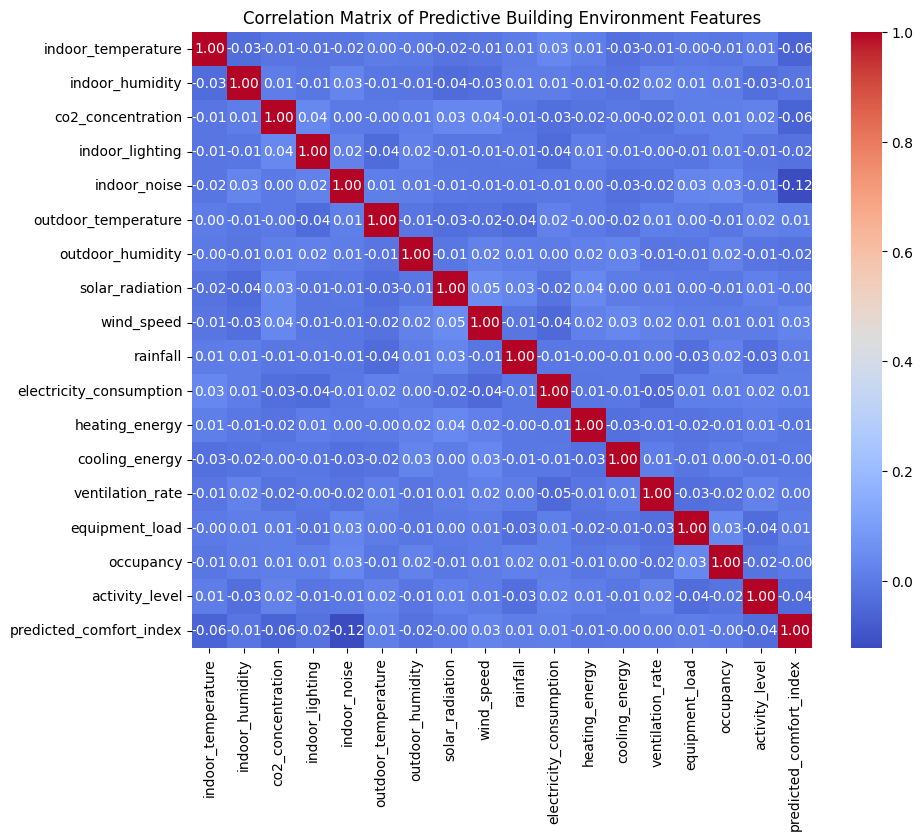

                               OLS Regression Results                              
Dep. Variable:     predicted_energy_demand   R-squared:                       0.952
Model:                                 OLS   Adj. R-squared:                  0.952
Method:                      Least Squares   F-statistic:                     2116.
Date:                     Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                             05:28:11   Log-Likelihood:                -4129.0
No. Observations:                     1920   AIC:                             8296.
Df Residuals:                         1901   BIC:                             8402.
Df Model:                               18                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

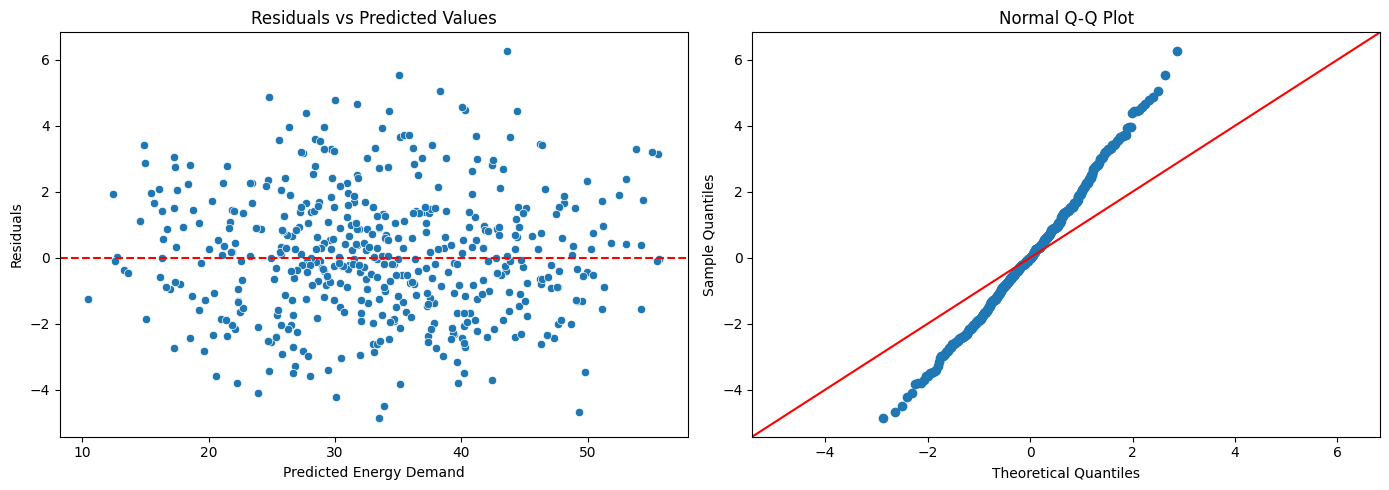

In [3]:
import os
import numpy as np
import pandas as pd
import kagglehub
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Download latest version of the dataset
kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)
print(f"Listing contents of: {path}")
!ls {path}

# 2. Load the dataset into a DataFrame
df2 = pd.read_csv(path + "/green_building_dataset.csv")

# Placeholder interface class matching 'inspector.df=df2' structure if required by your notebook
class DataInspector:
    def __init__(self):
        self.df = None
inspector = DataInspector()
inspector.df = df2

# 3. Exploration & Data Processing
print("\n--- Dataset Summary ---")
print(df2.info())
print("\nMissing values per column:\n", df2.isnull().sum())

# Define variables based on typical multi-source green building attributes
# Target variable: 'predicted_energy_demand'
target = 'predicted_energy_demand'

# Note: Based on multi-source data parameters (indoor conditions, outdoor weather, occupancy)
# We assume standard names present in environmental IoT datasets such as:
# ['indoor_temperature', 'outdoor_temperature', 'humidity', 'occupancy_count', 'lighting_intensity']
# If the exact schema names vary slightly, select corresponding numerical environmental factors from df2.columns.
potential_features = [col for col in df2.columns if col != target and df2[col].dtype in [np.float64, np.int64]]

print(f"\nAutomatically selected numerical parameters for exploration:\n{potential_features}")

# Filter out non-contributing or ID columns if any exist
features = [f for f in potential_features if f.lower() not in ['id', 'timestamp']]

# Drop rows with missing values in our subset (if any)
df_clean = df2[[target] + features].dropna()

X = df_clean[features]
y = df_clean[target]

# 4. Feature Selection Strategy: Multicollinearity Check via Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(X.correlation() if hasattr(X, 'correlation') else X.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Predictive Building Environment Features")
plt.show()

# 5. Split Dataset into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Add constant vector for the intercept term (beta_0) as required by statsmodels
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# 6. Fit the Ordinary Least Squares (OLS) Linear Regression Model
model = sm.OLS(y_train, X_train_sm).fit()

# Print comprehensive model summary (p-values, R-squared, t-statistics)
print(model.summary())

# 7. Model Evaluation and Performance Metrics
y_pred = model.predict(X_test_sm)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Testing Performance Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coefficient of Determination ($R^2$): {r2:.4f}")

# 8. Diagnostic Plots: Checking Linear Regression Assumptions
residuals = y_test - y_pred

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# Residuals vs Fitted values (Homoscedasticity evaluation)
sns.scatterplot(x=y_pred, y=residuals, ax=ax[0])
ax[0].axhline(y=0, color='r', linestyle='--')
ax[0].set_title('Residuals vs Predicted Values')
ax[0].set_xlabel('Predicted Energy Demand')
ax[0].set_ylabel('Residuals')

# Normality of Residuals (Q-Q plot)
sm.qqplot(residuals, line='45', ax=ax[1])
ax[1].set_title('Normal Q-Q Plot')

plt.tight_layout()
plt.show()